# Run 3 SIDM signal validation

Validates the privately-produced Run 3 signal LLPNanoAOD (`pp -> pscalar -> 2 dark photons -> lepton-jets`,
4Mu and 2Mu2E, four Run 3 eras, 2000 events/sample in 4 chunks) at **gen level**: measured/nominal proper
cτ, dark-photon mass, and lepton kinematics/collimation, read straight from `GenPart`. Samples are consumed
through the analysis location YAMLs (`sidm/configs/ntuples/signal_{4mu,2mu2e}_run3.yaml`) exactly as the
analysis would.

Proper cτ of a dark photon (pdgId 32) = |decay vertex - production vertex| / (p/m), the decay vertex being
its lepton daughter's production vertex — the same quantity the analysis lifetime study measures.

In [1]:
import sys, os
_root = os.getcwd().split("/sidm")[0]        # repo root, works from any clone
for _p in (_root, os.getcwd()):              # os.getcwd() = this study dir, where the helper lives
    if _p not in sys.path:
        sys.path.insert(1, _p)
import numpy as np, matplotlib.pyplot as plt, mplhep as hep
hep.style.use("CMS")
import run3_signal_validation as V
from sidm.tools import utilities

## 1. The analysis can find the samples via the Run 3 location YAML

In [2]:
fs = utilities.make_fileset(["4Mu_200GeV_1p2GeV_0p48mm"], "2022",
                            location_cfg="signal_4mu_run3.yaml", replace_xcache=True)
k = list(fs)[0]
print(k, "->", len(fs[k]["files"]), "chunk files; metadata:", fs[k]["metadata"])
print("first URL:", fs[k]["files"][0])

4Mu_200GeV_1p2GeV_0p48mm -> 4 chunk files; metadata: {'skim_factor': 1.0, 'is_data': False, 'year': '2022'}
first URL: root://cmseos.fnal.gov//store/group/lpcmetx/SIDM/run3_samplegen/outputs/2022/SIDM_BsTo2DpTo4Mu_MBs-200_MDp-1p2_ctau-0p48/SIDM_BsTo2DpTo4Mu_MBs-200_MDp-1p2_ctau-0p48_2022_j000.root


## 2. Lifetime: measured/nominal proper cτ across a representative set (both channels)

Six points spanning mass and cτ, both channels. A correctly-set lifetime gives measured/nominal ≈ 1.

In [3]:
points = [("4Mu_100GeV_0p25GeV_2p0mm", "signal_4mu_run3.yaml"),
          ("4Mu_200GeV_1p2GeV_4p8mm",  "signal_4mu_run3.yaml"),
          ("4Mu_1000GeV_5p0GeV_4p0mm", "signal_4mu_run3.yaml"),
          ("2Mu2E_150GeV_0p25GeV_1p3mm","signal_2mu2e_run3.yaml"),
          ("2Mu2E_500GeV_5p0GeV_8p0mm","signal_2mu2e_run3.yaml"),
          ("2Mu2E_1000GeV_1p2GeV_0p96mm","signal_2mu2e_run3.yaml")]
res = [V.analyze(s, "2022", cfg) for s, cfg in points]
print(f"{'sample':32s}{'nom(mm)':>9s}{'meas(mm)':>10s}{'meas/nom':>10s}{'dpMass':>9s}{'nMu':>7s}{'nEl':>7s}")
for r in res:
    print(f"{r['sample']:32s}{r['nom']:9g}{r['meas']:10.3f}{r['meas']/r['nom']:10.3f}"
          f"{r['dpmass'].mean():9.3f}{r['nmu']:7d}{r['nel']:7d}")

sample                            nom(mm)  meas(mm)  meas/nom   dpMass    nMu    nEl
4Mu_100GeV_0p25GeV_2p0mm                2     1.980     0.990    0.257   8000      0
4Mu_200GeV_1p2GeV_4p8mm               4.8     4.920     1.025    1.200   8000      0
4Mu_1000GeV_5p0GeV_4p0mm                4     4.093     1.023    5.000   8000      0
2Mu2E_150GeV_0p25GeV_1p3mm            1.3     1.289     0.991    0.256   4000   4000
2Mu2E_500GeV_5p0GeV_8p0mm               8     7.875     0.984    5.000   4000   4000
2Mu2E_1000GeV_1p2GeV_0p96mm          0.96     0.936     0.974    1.201   4000   4000


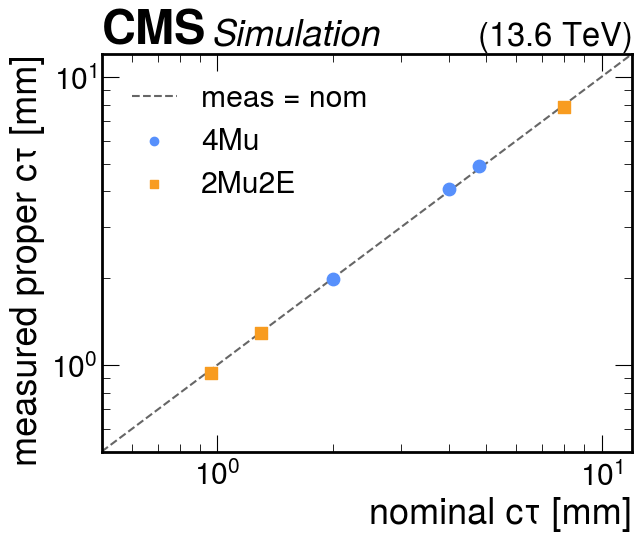

In [4]:
fig, ax = plt.subplots(figsize=(7,6))
for r in res:
    m = "o" if r["sample"].startswith("4Mu") else "s"
    c = "C0" if r["sample"].startswith("4Mu") else "C1"
    ax.scatter(r["nom"], r["meas"], marker=m, color=c, s=80, zorder=3)
lo, hi = 0.5, 12
ax.plot([lo,hi],[lo,hi], "k--", alpha=0.6, label="meas = nom")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
ax.set_xlabel("nominal cτ [mm]"); ax.set_ylabel("measured proper cτ [mm]")
ax.scatter([],[],marker="o",color="C0",label="4Mu"); ax.scatter([],[],marker="s",color="C1",label="2Mu2E")
ax.legend(); hep.cms.label("", data=False, com=13.6, ax=ax)
plt.tight_layout(); plt.show()

### Per-era: the same point validated in each of the four eras

With two chunks per era the per-point statistical precision is ≈2%, so the observed meas/nom
spread (≈0.97–1.02) is consistent with unity across all four eras.

In [5]:
for era in ["2022","2022EE","2023","2023BPix"]:
    r = V.analyze("4Mu_200GeV_1p2GeV_0p48mm", era, "signal_4mu_run3.yaml", nfiles=2)
    print(f"{era:9s} 4Mu_200GeV_1p2GeV_0p48mm: meas/nom={r['meas']/r['nom']:.3f}  "
          f"({len(r['proper_mm'])} dark photons in 2 chunks)")

2022      4Mu_200GeV_1p2GeV_0p48mm: meas/nom=1.015  (2000 dark photons in 2 chunks)


2022EE    4Mu_200GeV_1p2GeV_0p48mm: meas/nom=0.985  (2000 dark photons in 2 chunks)


2023      4Mu_200GeV_1p2GeV_0p48mm: meas/nom=0.972  (2000 dark photons in 2 chunks)


2023BPix  4Mu_200GeV_1p2GeV_0p48mm: meas/nom=1.000  (2000 dark photons in 2 chunks)


## 3. Kinematics for one point (4Mu, M_Bs=200, M_Zd=1.2, cτ=4.8 mm)

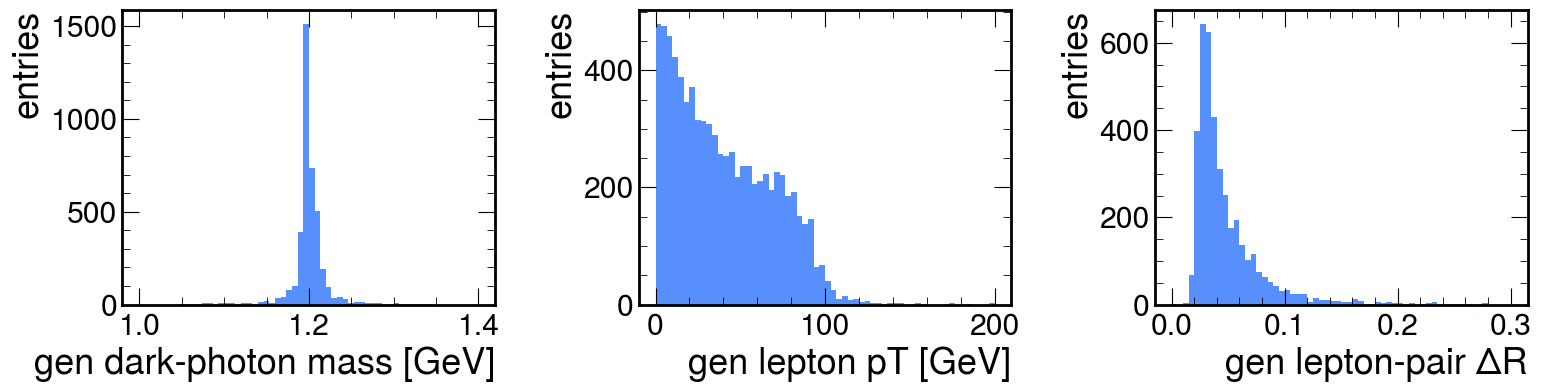

dark-photon mass mean=1.2000 GeV; median lepton pT=35.0 GeV; median ΔR(ll)=0.038  (collimated lepton pairs from a 1.2 GeV dark photon boosted by a 200 GeV pseudoscalar)


In [6]:
r = res[1]
fig, axs = plt.subplots(1, 3, figsize=(16,4.5))
axs[0].hist(r["dpmass"], bins=60, range=(1.0,1.4)); axs[0].set_xlabel("gen dark-photon mass [GeV]")
axs[1].hist(np.clip(r["lep_pt"], 0, 200), bins=60, range=(0,200)); axs[1].set_xlabel("gen lepton pT [GeV]")
axs[2].hist(r["dR"], bins=60, range=(0,0.3)); axs[2].set_xlabel("gen lepton-pair ΔR")
for a in axs: a.set_ylabel("entries")
plt.tight_layout(); plt.show()
print(f"dark-photon mass mean={r['dpmass'].mean():.4f} GeV; median lepton pT={np.median(r['lep_pt']):.1f} GeV; "
      f"median ΔR(ll)={np.median(r['dR']):.3f}  (collimated lepton pairs from a 1.2 GeV dark photon boosted by a 200 GeV pseudoscalar)")

## 4. Full grid: measured/nominal proper cτ over all 180 points (both channels)

Loads the full GEN-level scan (`run3_samplegen/validation/` on EOS): every point, every cτ.

180 points scanned; meas/nom mean=0.995 std=0.030 min=0.917 max=1.061; within 10% of 1.0: 180/180


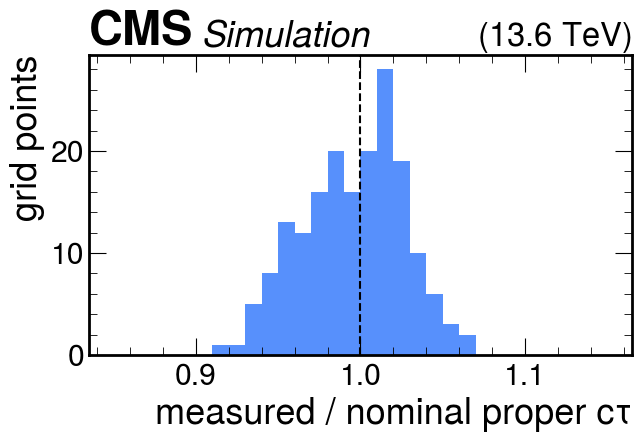

In [7]:
rows = V.load_grid_scan()
mn = np.array([x["meas_over_nom"] for x in rows if x["meas_over_nom"] > 0])
print(f"{len(rows)} points scanned; meas/nom mean={mn.mean():.3f} std={mn.std():.3f} "
      f"min={mn.min():.3f} max={mn.max():.3f}; within 10% of 1.0: {int((abs(mn-1)<=0.1).sum())}/{len(mn)}")
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(mn, bins=30, range=(0.85,1.15))
ax.axvline(1.0, color="k", ls="--"); ax.set_xlabel("measured / nominal proper cτ"); ax.set_ylabel("grid points")
hep.cms.label("", data=False, com=13.6, ax=ax); plt.tight_layout(); plt.show()

## 5. Displaced content — the `DSAMuon` collection the search needs

The custom LLPNanoAOD tier exists to keep the displaced standalone muons the standard tiers slim
away. For one displaced point (4Mu, M_Bs=200, M_Zd=1.2, **cτ = 4.8 mm**) we open a produced nano and
confirm the `DSAMuon` table is populated (~4 per event) and genuinely displaced — broad, large
transverse impact parameters |dxy|.
The |dxy| scale (median ≈4 cm for a proper cτ of 4.8 mm) is the lab-frame boost at work: at
$M_{B_s}$=200, $M_{Z_d}$=1.2 GeV the dark photons carry βγ ~ 80, so lab decay lengths are
~βγ·cτ ≫ cτ.

500 events; DSAMuon/event: mean 4.07, max 8, >=2 in 96% of events
DSAMuon pT median 21.8 GeV; |dxy| median 37 mm, 90th pct 497 mm  (broad/large -- the displaced standalone-muon signature)


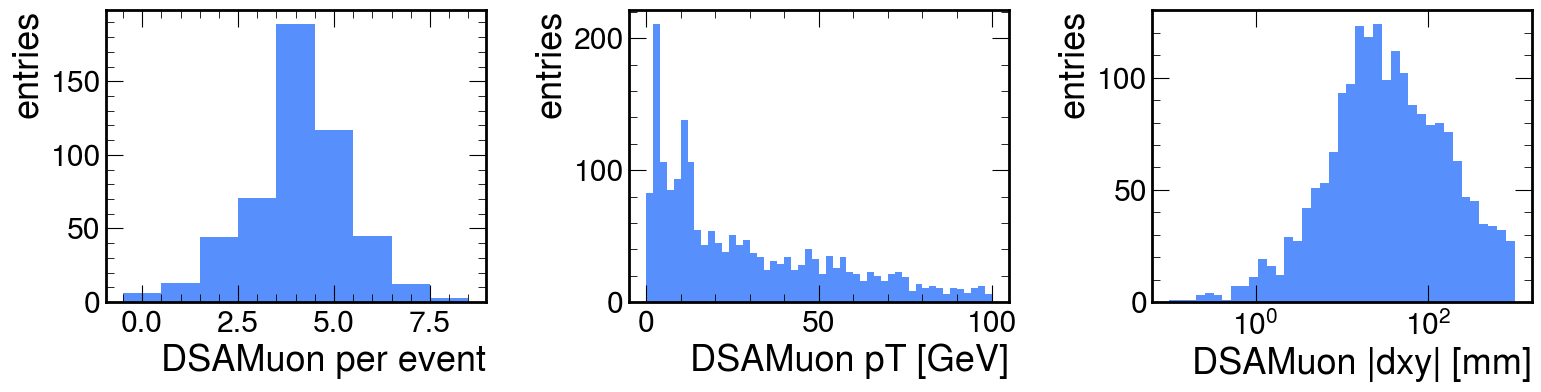

In [8]:
import uproot, awkward as ak
fs = utilities.make_fileset(["4Mu_200GeV_1p2GeV_4p8mm"], "2022", max_files=2,
                            location_cfg="signal_4mu_run3.yaml", replace_xcache=True)
ev = uproot.open(fs[list(fs)[0]]["files"][0])["Events"].arrays(["nDSAMuon", "DSAMuon_pt", "DSAMuon_dxy"])
ndsa = ak.to_numpy(ev["nDSAMuon"])
pt   = ak.to_numpy(ak.flatten(ev["DSAMuon_pt"]))
dxy  = ak.to_numpy(ak.flatten(abs(ev["DSAMuon_dxy"]))) * 10.0     # DSAMuon_dxy is in cm -> mm
print(f"{len(ndsa)} events; DSAMuon/event: mean {ndsa.mean():.2f}, max {int(ndsa.max())}, "
      f">=2 in {100*(ndsa>=2).mean():.0f}% of events")
print(f"DSAMuon pT median {np.median(pt):.1f} GeV; |dxy| median {np.median(dxy):.0f} mm, "
      f"90th pct {np.percentile(dxy,90):.0f} mm  (broad/large -- the displaced standalone-muon signature)")

fig, axs = plt.subplots(1, 3, figsize=(16,4.5))
axs[0].hist(ndsa, bins=range(0,10), align="left"); axs[0].set_xlabel("DSAMuon per event")
axs[1].hist(pt, bins=50, range=(0,100)); axs[1].set_xlabel("DSAMuon pT [GeV]")
axs[2].hist(dxy, bins=np.logspace(-1, 3, 40)); axs[2].set_xscale("log"); axs[2].set_xlabel("DSAMuon |dxy| [mm]")
for a in axs: a.set_ylabel("entries")
plt.tight_layout(); plt.show()

## 6. Cross-check vs the 2018 (v10) samples

Same grid point (4Mu, M_Bs=200, M_Zd=1.2, cτ=4.8 mm), 2018 v10 vs Run 3 2022, normalized shapes.
How to read it: the dark-photon mass must and does agree exactly (it is fixed by the generation), and the
measured proper cτ agrees within the ~3% per-point statistical scatter of a finite-sample
decay-length measurement (cf. the grid-wide spread in §4); at these sample sizes a KS test
resolves sub-percent shifts, so a formally small KS p-value for cτ is not evidence of a
generation disagreement. The lepton-level distributions differ **by construction**: the v10 production applied
gen-level lepton acceptance cuts (a hard |η| < 2.4 edge and pT ≳ 1 GeV, measured on the v10 gen
leptons themselves), while the Run 3 production applies no gen filter (full lepton phase space).
The third curve applies the v10 acceptance to the Run 3 leptons; the shapes then largely close.
The small remaining difference (a few-percent softer dark-photon pT in Run 3, hence slightly softer
leptons and wider pairs) traces to a parton-shower settings-block difference with respect to the
Run 2 fragment, documented in SampleFactory `sidm_run3/PROVENANCE.md`. Two practical consequences:
efficiency denominators differ between v10 and Run 3 (v10 events were pre-filtered into acceptance),
and any 2018↔Run 3 shape comparison should first apply |η| < 2.4, pT > 1 GeV to the Run 3 leptons.

invariant dark-photon mass : 2018 mean=1.201  Run3 mean=1.2  KS D=0.008 p=0.99
invariant proper ctau      : 2018 mean=4.801  Run3 mean=4.92  KS D=0.026 p=0.037
2018 gen-lepton acceptance edge: max|eta| = 2.398, min pT = 1.14 GeV (Run3: 6.05, 0.09 GeV)
fraction of Run3 leptons inside the v10 acceptance: 0.854


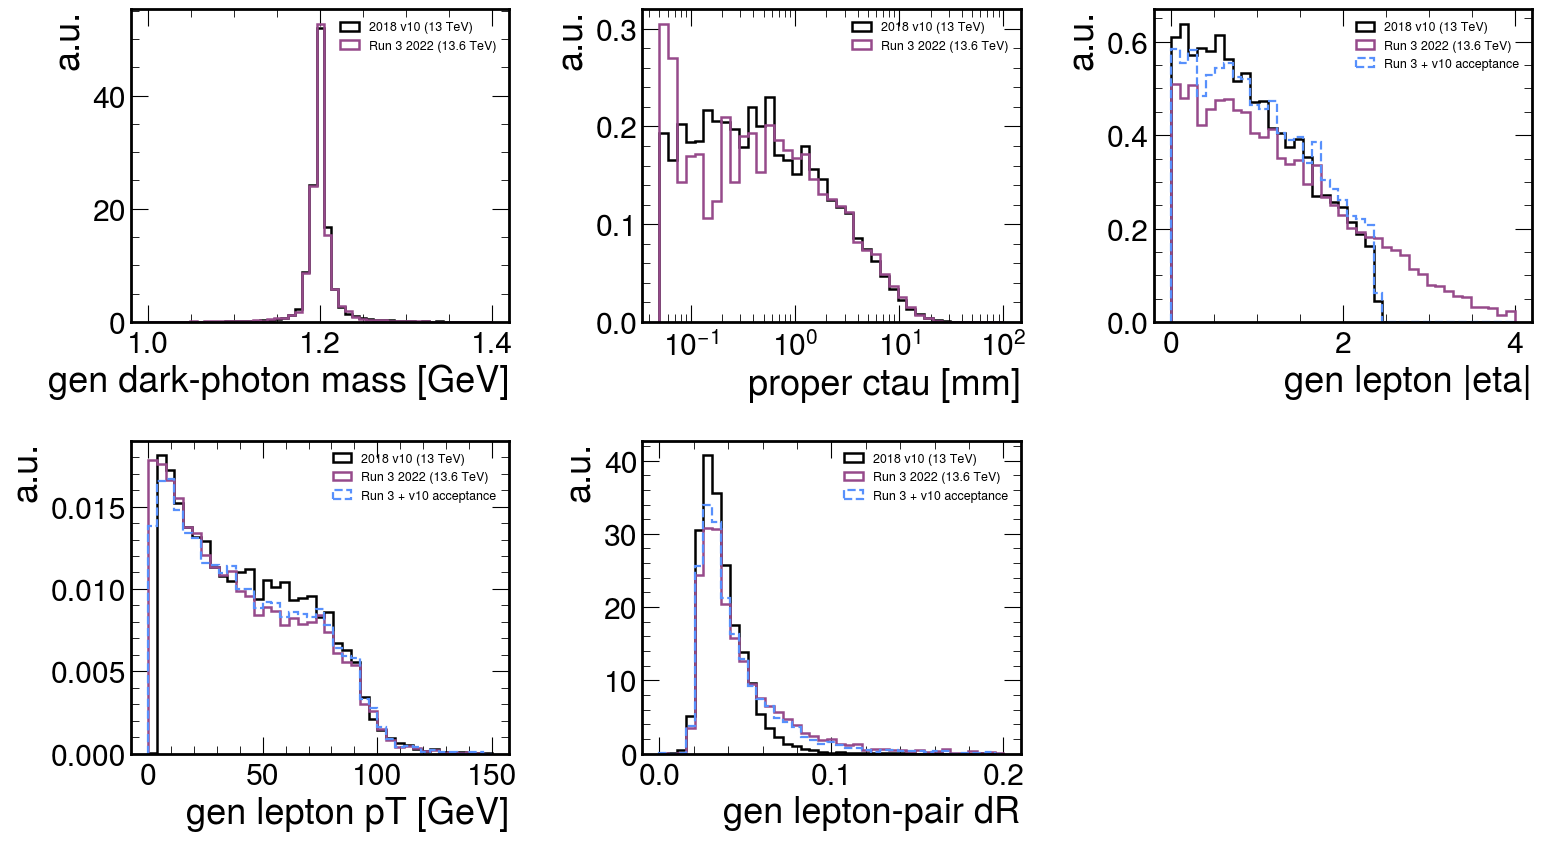

In [9]:
from scipy.stats import ks_2samp
pt_name = "4Mu_200GeV_1p2GeV_4p8mm"
r18  = V.analyze(pt_name, "llpNanoAOD_v2", "signal_4mu_v10.yaml", nfiles=2)
r22  = V.analyze(pt_name, "2022", "signal_4mu_run3.yaml", nfiles=4)
r22c = V.analyze(pt_name, "2022", "signal_4mu_run3.yaml", nfiles=4, lep_abseta_max=2.4, lep_pt_min=1.0)

for k, lab in [("dpmass", "dark-photon mass"), ("proper_mm", "proper ctau")]:
    ks = ks_2samp(r18[k], r22[k])
    print(f"invariant {lab:17s}: 2018 mean={np.mean(r18[k]):.4g}  Run3 mean={np.mean(r22[k]):.4g}  KS D={ks.statistic:.3f} p={ks.pvalue:.2g}")
print(f"2018 gen-lepton acceptance edge: max|eta| = {r18['lep_abseta'].max():.3f}, min pT = {r18['lep_pt'].min():.2f} GeV "
      f"(Run3: {r22['lep_abseta'].max():.2f}, {r22['lep_pt'].min():.2f} GeV)")
print(f"fraction of Run3 leptons inside the v10 acceptance: {len(r22c['lep_pt'])/len(r22['lep_pt']):.3f}")

fig, axs = plt.subplots(2, 3, figsize=(16, 9)); axs = axs.ravel()
def three(ax, key, bins, xlab, logx=False, cut=True):
    ax.hist(r18[key], bins=bins, density=True, histtype="step", lw=1.8, color="k", label="2018 v10 (13 TeV)")
    ax.hist(r22[key], bins=bins, density=True, histtype="step", lw=1.8, color="C3", label="Run 3 2022 (13.6 TeV)")
    if cut:
        ax.hist(r22c[key], bins=bins, density=True, histtype="step", lw=1.6, color="C0", ls="--",
                label="Run 3 + v10 acceptance")
    if logx: ax.set_xscale("log")
    ax.set_xlabel(xlab); ax.set_ylabel("a.u."); ax.legend(fontsize=9)
three(axs[0], "dpmass", np.linspace(1.0, 1.4, 50), "gen dark-photon mass [GeV]", cut=False)
three(axs[1], "proper_mm", np.logspace(np.log10(0.05), np.log10(100), 40), "proper ctau [mm]", logx=True, cut=False)
three(axs[2], "lep_abseta", np.linspace(0, 4, 40), "gen lepton |eta|")
three(axs[3], "lep_pt", np.linspace(0, 150, 40), "gen lepton pT [GeV]")
three(axs[4], "dR", np.linspace(0, 0.2, 40), "gen lepton-pair dR")
axs[5].axis("off")
plt.tight_layout(); plt.show()

## 7. High-statistics kinematics across the grid

The enhanced-stats grid (100k events/point on the reduced grid) lets us look at the gen-level
lepton-jet kinematics at high precision. At fixed $M_{Z_d}=1.2$ GeV, as $M_{B_s}$ (hence the
dark-photon boost) rises from 200 to 800 GeV, the collimated dilepton $\Delta R$ tightens
($\langle\Delta R\rangle$ from $\sim$0.05 to $\sim$0.01, all well inside the $R=0.4$ lepton-jet
cone) and the lepton $p_T$ hardens (median $\sim$35 to $\sim$141 GeV). The dark-photon mass sits
at 1.199 GeV throughout. This is the high-stat companion to the single-point kinematics of §3.

**Sample tiers and era coverage.** The full 180-point grid was produced at 2000 events/point;
a reduced 36-point grid (one intermediate-cτ point per mass pair and channel) is being extended
to 100k events/point, 2022 first. Sections 7–9 use the eighteen 2022 reduced-grid points that
have reached full statistics. The gen-level lifetime checks (§2) cover all four eras; the
reconstruction- and trigger-level checks (§§7–9) were established on 2022 and are now extended
to **all four eras** below (the production campaign is complete: every reduced-grid point in every
era at 100k events).

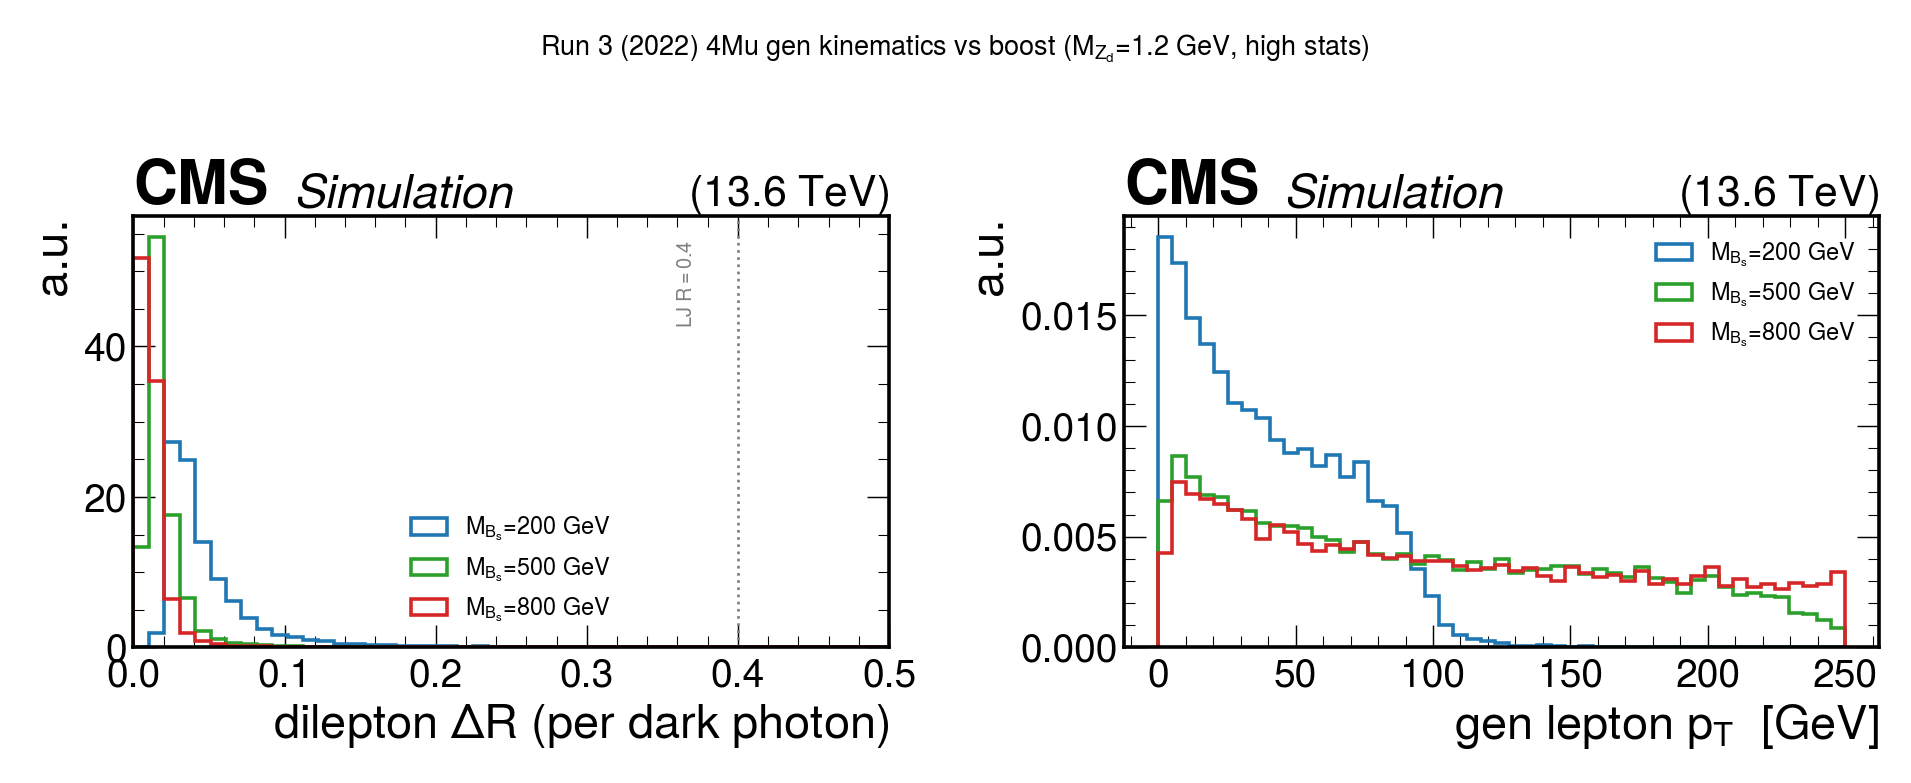

In [ ]:
import run3_study_plots as P
P.fig_kinematics("4Mu")

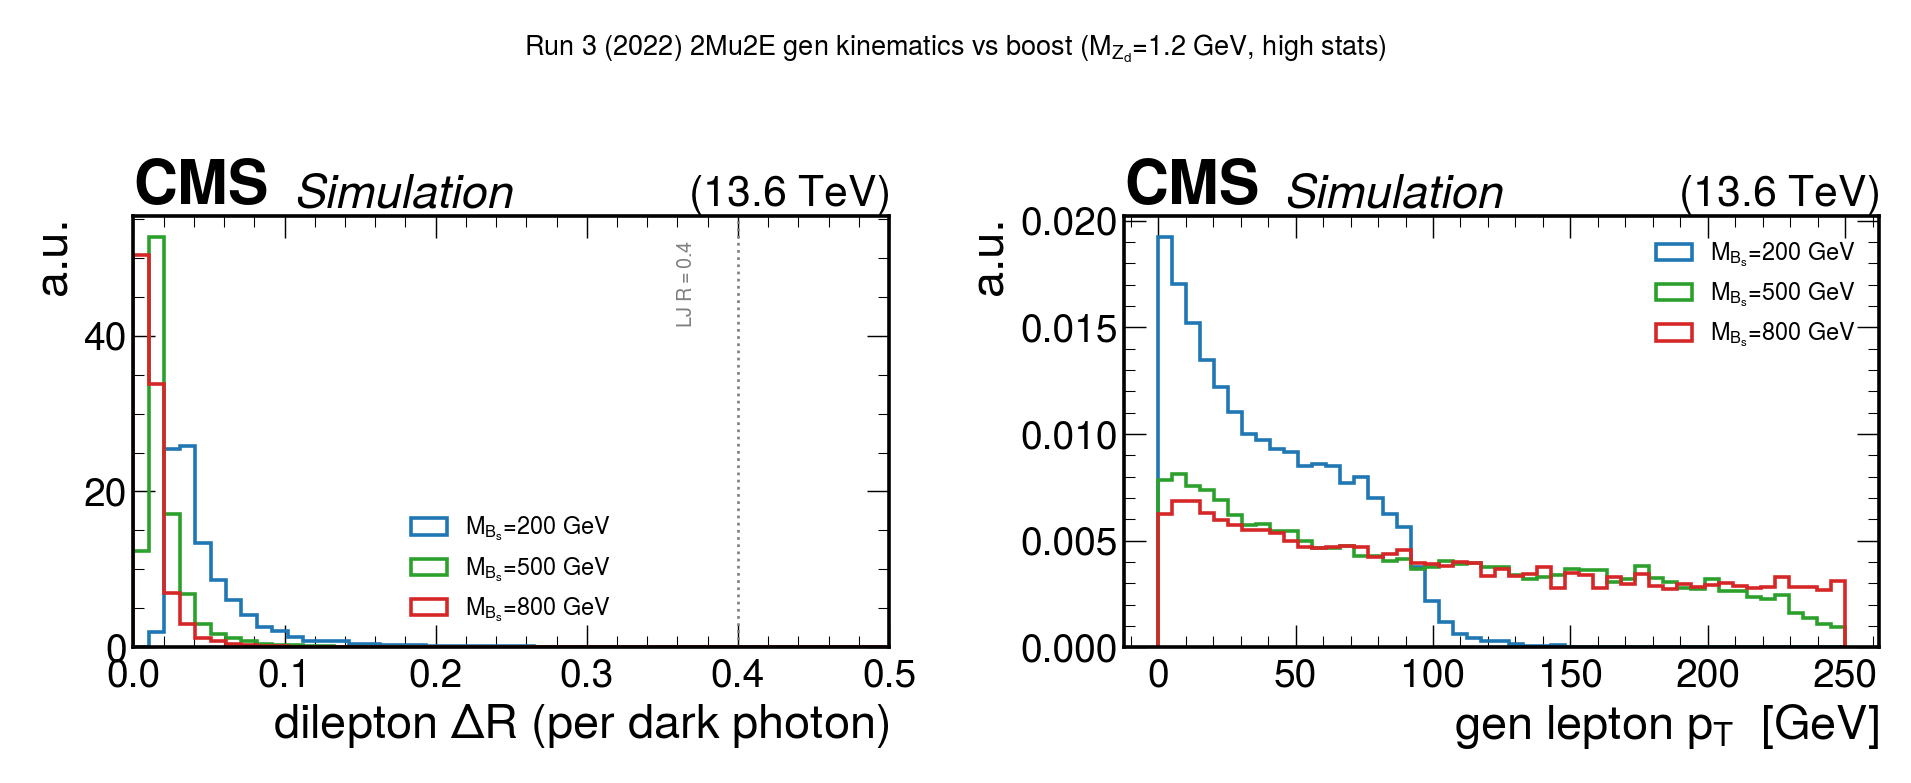

In [ ]:
P.fig_kinematics("2Mu2E")

### All four eras: generated kinematics are era-identical

The same gridpacks and generator fragment drive every era — only detector conditions differ —
so the generated kinematics must coincide. They do: overlaying one representative point across
the four eras, the ΔR and lepton-$p_T$ shapes lie on top of each other (means agree to ~1%),
and the dark-photon mass is 1.199 GeV everywhere.

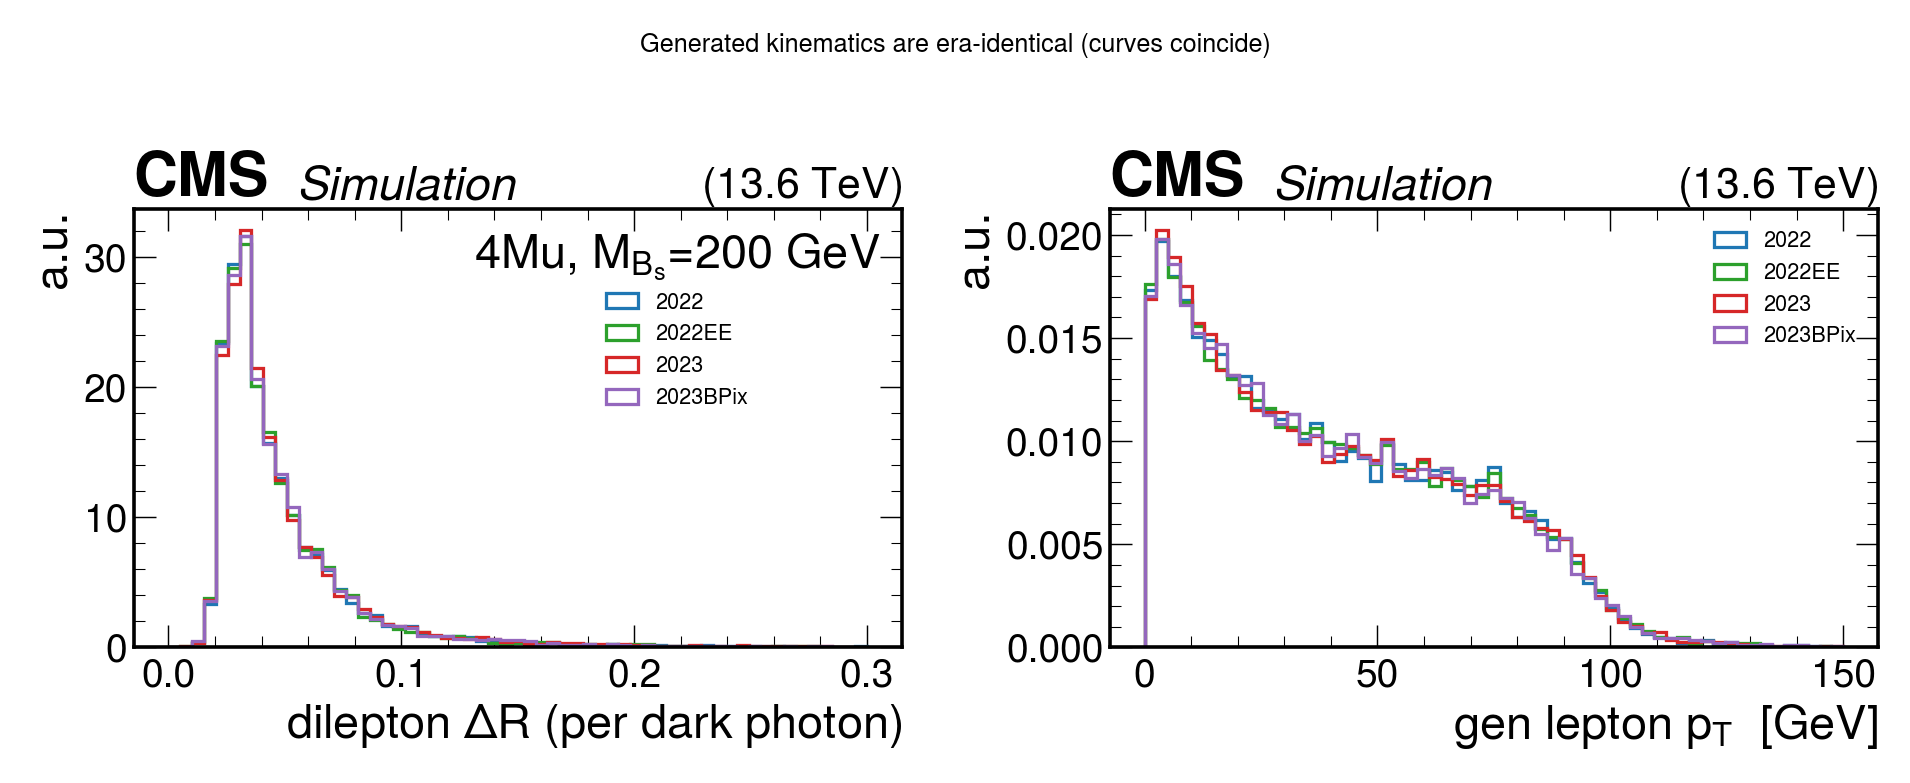

In [ ]:
P.fig_kinematics_eras()

## 8. Signal reconstruction — lepton-jet clustering & DSA cross-cleaning

The search reconstructs each dark photon as a **lepton jet (LJ)**: an anti-$k_T$ ($R=0.4$) jet
clustered from muons, displaced-standalone (DSA) muons, electrons and photons, split into
**$\mu$-type LJs** (any muon constituent) and **e$\gamma$-type LJs** (electrons/photons only, no
fixed object count — a collimated $e^+e^-$ often merges into a single photon). The signal
signatures are `= 2 μ-LJ` (4Mu) and `= 1 μ-LJ & = 1 eγ-LJ` (2Mu2E). Two things are checked here.

**(a) Do the *generated* leptons cluster into LJs the same way in Run 3 and Run 2?** This is a
sample property (it depends on generated collimation/multiplicity, not the detector). Reconstructing
with loose kinematic preselection (clustering geometry) on a common "both dark-photon pairs in
$|\eta|<2.4$, $p_T>1$ GeV" acceptance denominator — a reconstruction of the gen acceptance the 2018 v10 production
applied, imposed identically on both eras — **Run 3 matches Run 2**: the mean Run 3 $-$ Run 2
difference is -0.08% (4Mu, max |diff| 0.12%) and +0.07% (2Mu2e, max 0.37%).
The eγ leg is gen-matched to the generated $ee$ dark photon; error bars are Clopper–Pearson binomial.
(The 4Mu inclusive metric is near-saturated at ~99% — in this loose mode un-cleaned DSA fakes make
≥2 μ-LJ nearly automatic — so its sub-0.12% agreement is partly a ceiling effect; the 2μ2e
requirement, with its gen-matched eγ leg, is the more discriminating geometry check.)

**(b) Does the analysis's DSA cross-cleaning behave correctly on the Run 3 samples?** Applying the
full SIDM LJ-source object selection (PF-muon looseID+$p_T$>5; DSA $p_T$>10+displacedID + **segment-
match cross-cleaning** (the dominant numMatch/nSegments < 0.34 term of the SR cut, applied
one-sidedly — stricter than the full cut, which also lets a DSA survive via its dR and
match-count escapes, so the residual extra-LJ tail shown is a lower bound); e $p_T$>10; γ $p_T$>20+cutBased), the **$\mu$-LJ multiplicity collapses to
the expected signal count** (2 for 4Mu, 1 for 2Mu2E) in *both* eras — the un-cleaned DSA fakes (a
37–54% extra-LJ tail without the selection) are removed. The multiplicity comparison is made on the common in-acceptance denominator (v10 is gen-filtered
at production, Run 3 is not — a full-phase-space histogram would show a spurious acceptance gap
in the signal bin). The reconstructed content is well-behaved and the DSA handling works on the
Run 3 samples.

**Scope.** This validates the sample-level clustering and the DSA cross-cleaning — not the full
per-object signal-region *yield*. A like-for-like Run 3 ↔ Run 2 comparison of the per-object
reconstruction/ID efficiency is not meaningful with these samples, because the object-ID branches
and working points differ between the 2018 and 2022 NanoAOD formats (notably the electron MVA ID),
and those per-era differences are exactly what the analysis's per-era efficiencies/scale factors
absorb. (Concretely: in this mode no electron ID is applied — the eγ leg is gen-matched instead — and
the 2μ2e object-level efficiency differs by up to ~25pp between Run 3 and v10, as expected.
In the analysis itself the 4μ signal cut additionally requires the two leading LJs to each
contain ≥2 muons with LJ $p_T$>30 GeV; the counting here uses any-muon-content LJs, which
coincides for collimated signal.) The definitive Run 3 signal-region efficiency needs the full processor — see §10.

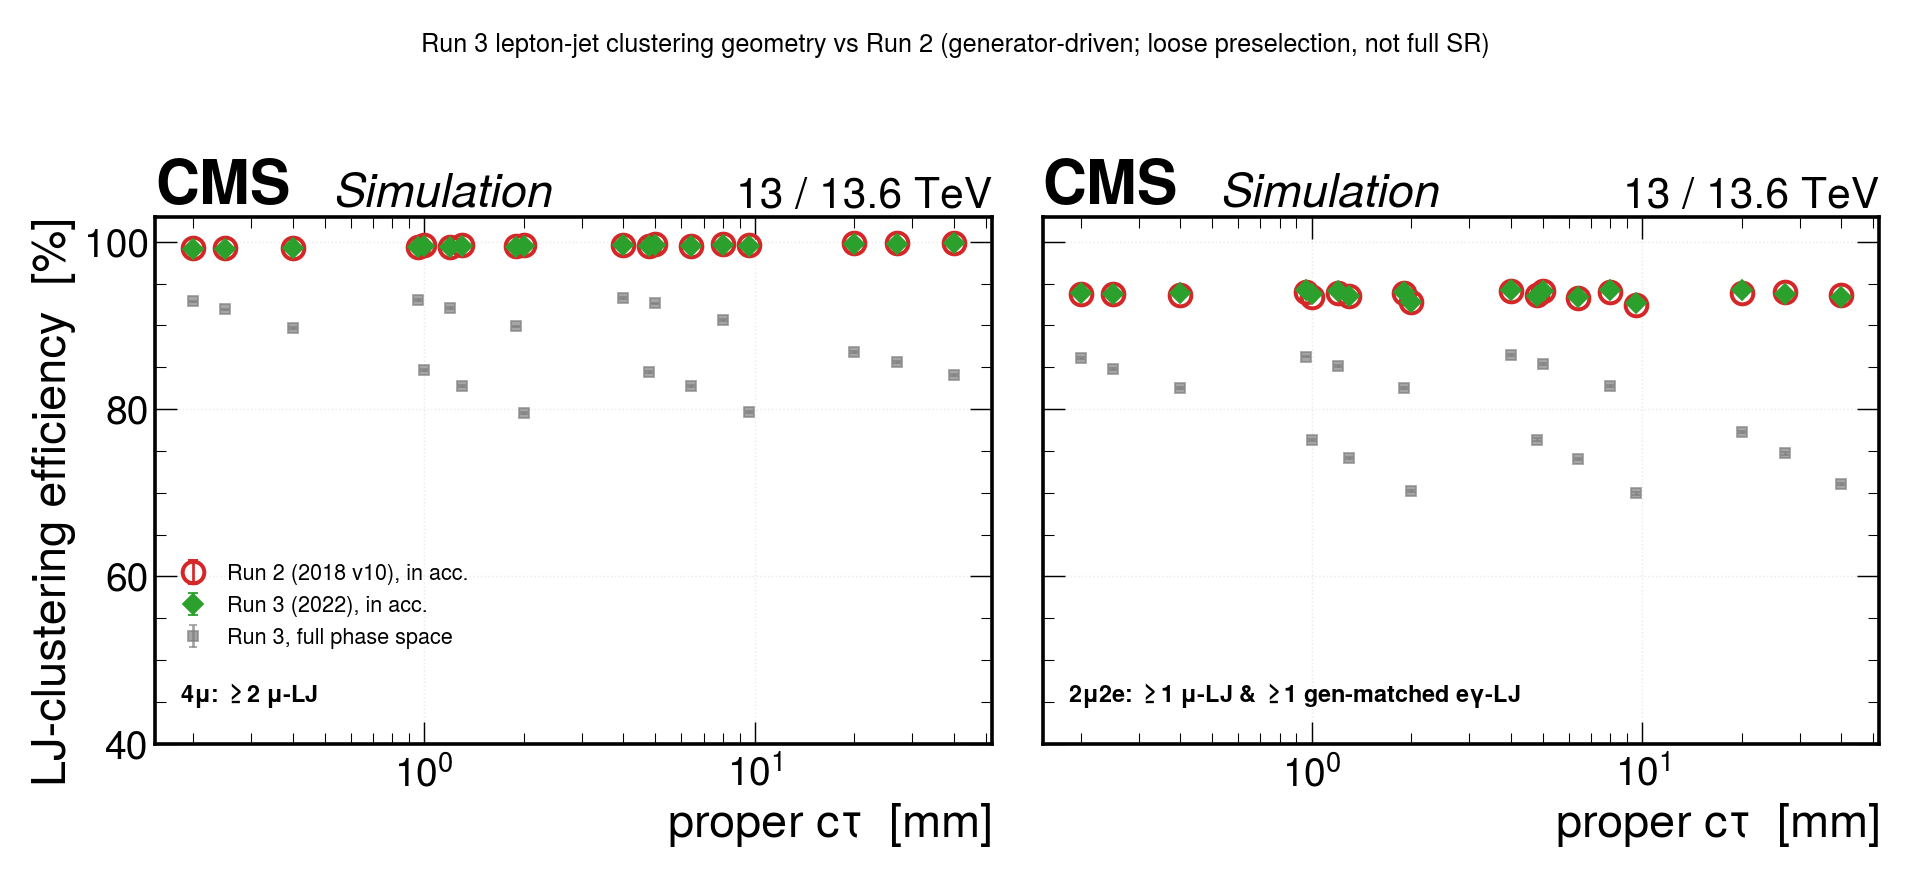

In [ ]:
P.fig_geometry_efficiency()

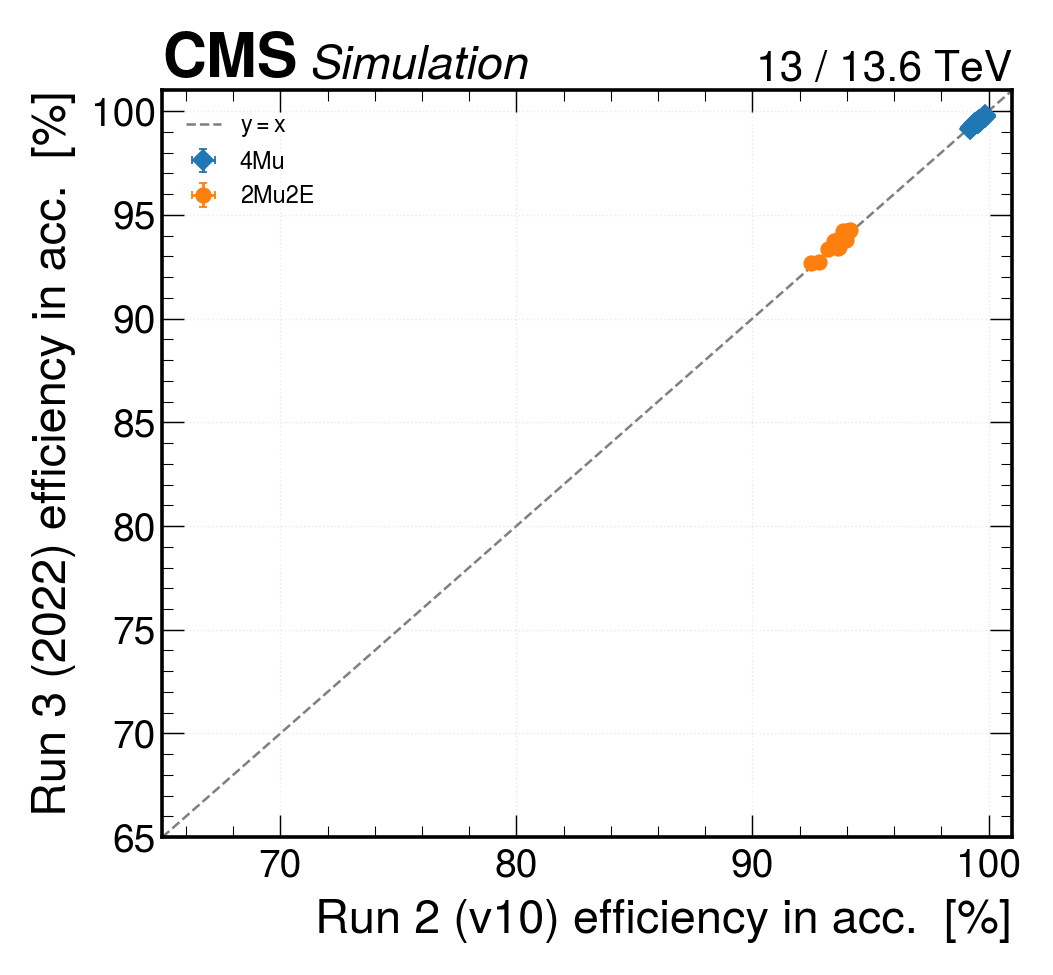

In [ ]:
P.fig_geometry_agreement()

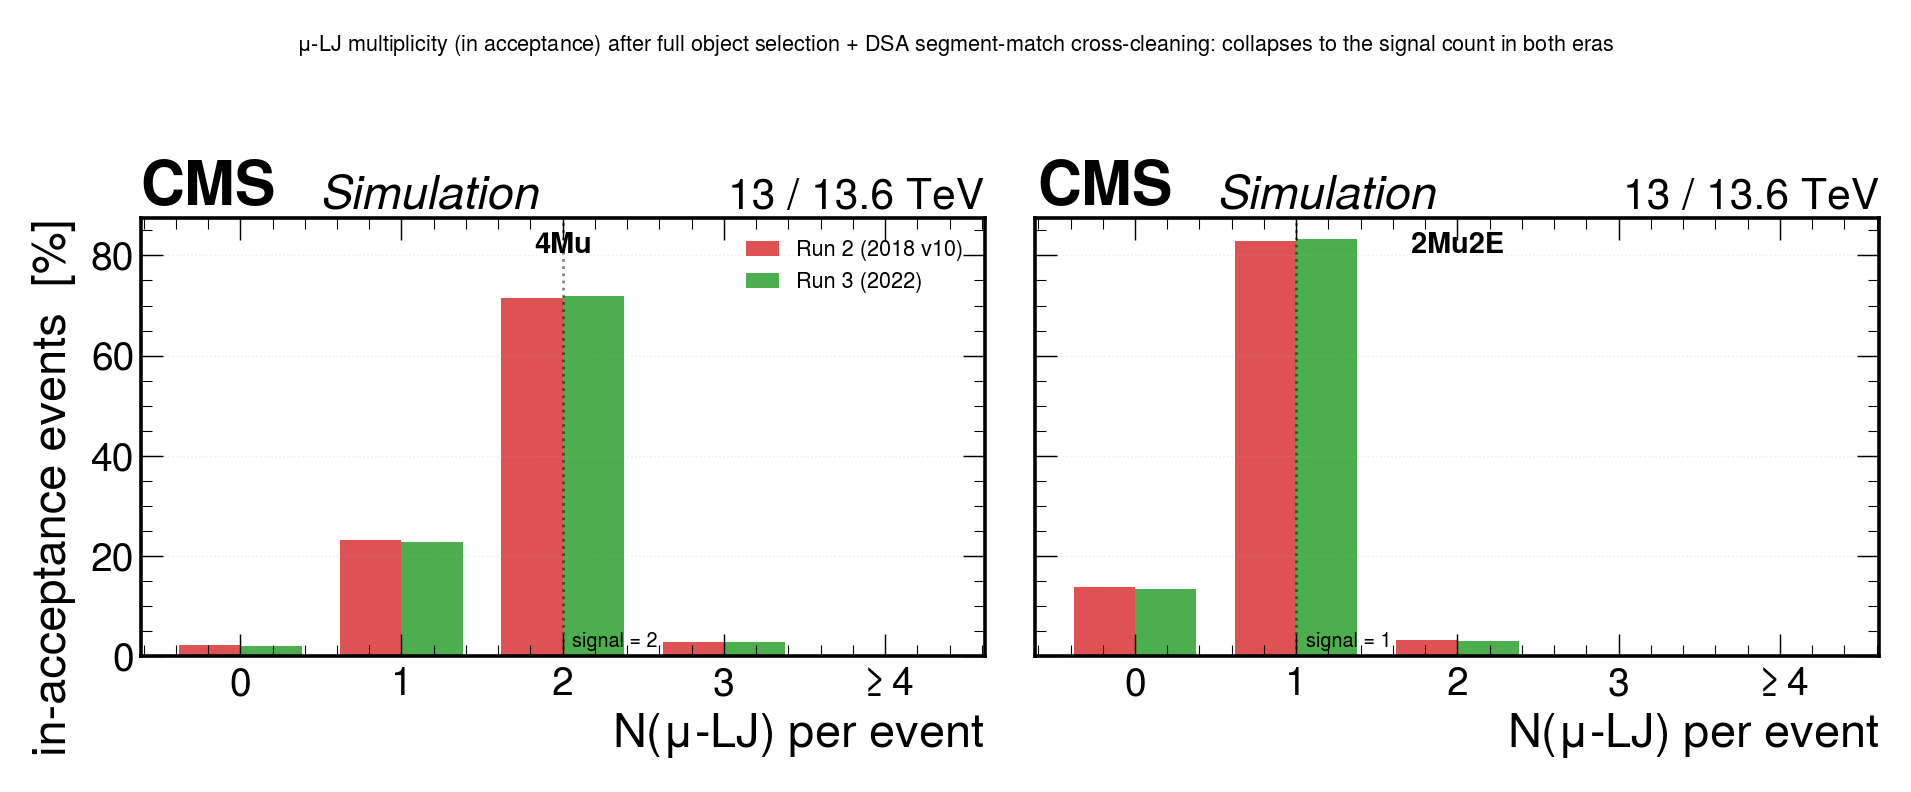

In [ ]:
P.fig_mu_multiplicity()

### All four eras: clustering geometry and DSA cross-cleaning

The same geometry and cross-cleaning checks, repeated per era against the same Run 2 (2018 v10)
reference, now over the **full 36-point reduced grid** (the 2022 figures above are likewise
updated to the full grid; the hyper-boosted low-$M_{Z_d}$/high-$M_{B_s}$ corners have lower
absolute efficiency, and agree between eras all the same).

LJ-clustering geometry, mean Run 3 − Run 2 in-acceptance efficiency difference per era:

| era | 4μ mean (max\|d\|) | 2μ2e mean (max\|d\|) |
|---|---|---|
| 2022 | -0.08% (0.12%) | +0.08% (0.37%) |
| 2022EE | -0.08% (0.21%) | -0.47% (0.91%) |
| 2023 | -0.03% (0.11%) | -0.22% (0.77%) |
| 2023BPix | -0.02% (0.11%) | -0.22% (0.75%) |

μ-LJ multiplicity signal-bin fraction (in acceptance, after full object selection + DSA
cross-cleaning) — Run 3 vs Run 2 per era:

| era | 4μ signal-bin frac (Run 3 / Run 2) | 2μ2e (Run 3 / Run 2) |
|---|---|---|
| 2022 | 72% / 72% | 83% / 83% |
| 2022EE | 72% / 72% | 83% / 83% |
| 2023 | 73% / 72% | 83% / 83% |
| 2023BPix | 73% / 72% | 83% / 83% |

Sub-percent geometry agreement and matching multiplicity collapse in every era: the Run 3
samples reconstruct like Run 2 across the entire campaign.

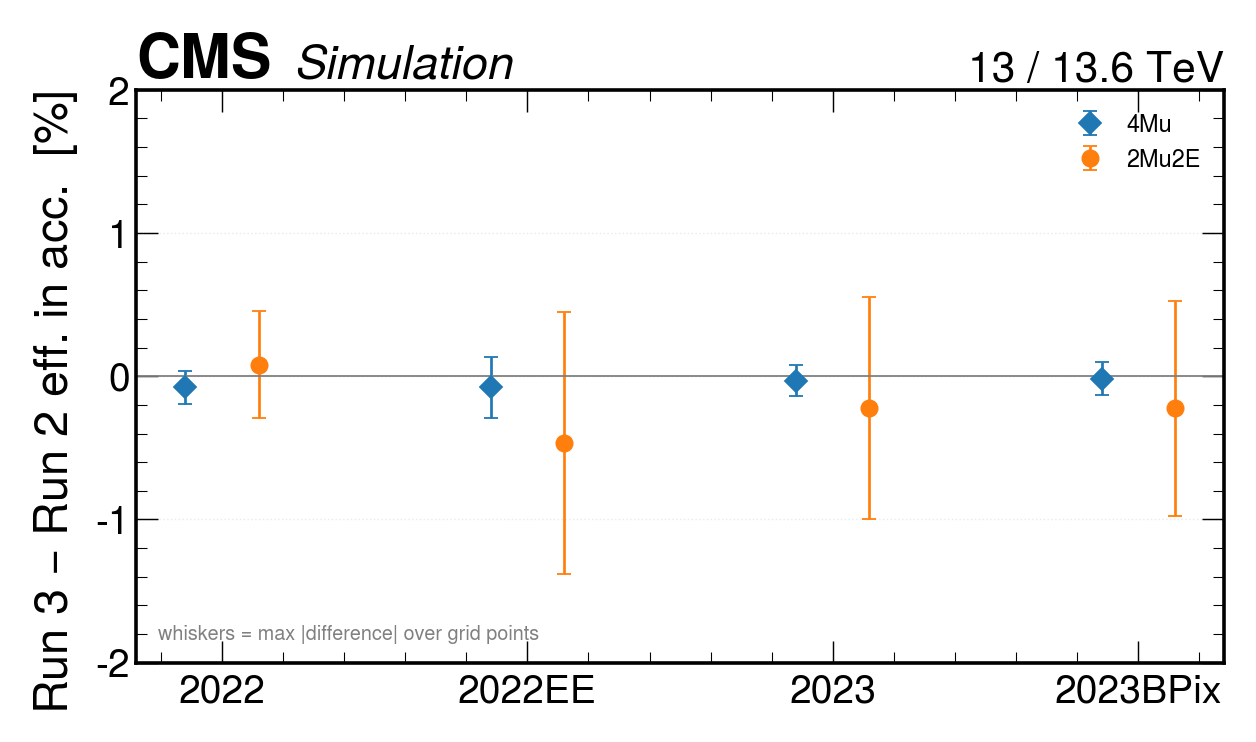

In [ ]:
P.fig_geometry_eras()

## 9. Trigger efficiency (Run 3 menu characterization)

For each grid point we evaluate the HLT paths stored in the LLPNanoAOD on the Run 3 signal, per path
group and as the combined Run 3 displaced-dimuon OR, and compare with the 2018-menu L2 subset (all
evaluated **on the Run 3 MC** — this characterizes the Run 3 menu on signal; it is not a 2018/2022
trigger-equivalence test). The full OR is by construction $\geq$ the 2018 subset; the useful content
is the gain and where it arises. On the high-stat points the Run 3 OR adds efficiency over the
2018-only set: 80% → 86% (4Mu, $+6$%) and 27% → 39%
(2Mu2e, $+12$%). The L3-DxyMin paths turn on in the displaced regime; the VetoL3 paths
genuinely fire (up to $\sim$37% at the longest $c\tau$). 2Mu2e is roughly half of 4Mu — only one
dark photon is muonic and seeds the dimuon trigger.

In the figure, small faint markers are the 2000-event grid points (stat. uncertainty ≈1%); the
large markers with binomial error bars are the 100k-event points, from which the quoted means
are computed. The VetoL3 subset is drawn explicitly: its efficiency is cτ-dependent and peaks
at the longest lifetimes (up to ≈37%).

Two interpretation caveats. On the Run 3 menu the legacy 2018 paths are seeded by the expanded
Run 3 L1 menu, so the "2018-menu" curve means *the 2018 HLT selection under Run 3 L1* (the
same definition used in the published Run 3 trigger comparisons), not a true 2018 efficiency.
And in early-2022 data the displaced (unconstrained-$p_T$) L1 seeds were disabled until
late July 2022, while the MC has them active — so for the 2022 era the MC is slightly
optimistic for large-displacement signals; data-driven trigger scale factors are expected
downstream in any case. The trigger OR is era-dependent: the cosmic-seeded VetoL3 and hybrid L2+L3 paths exist only in
the 2022EE/2023 menus; the canonical scans of all four eras, with per-family exclusive marginals,
follow below.

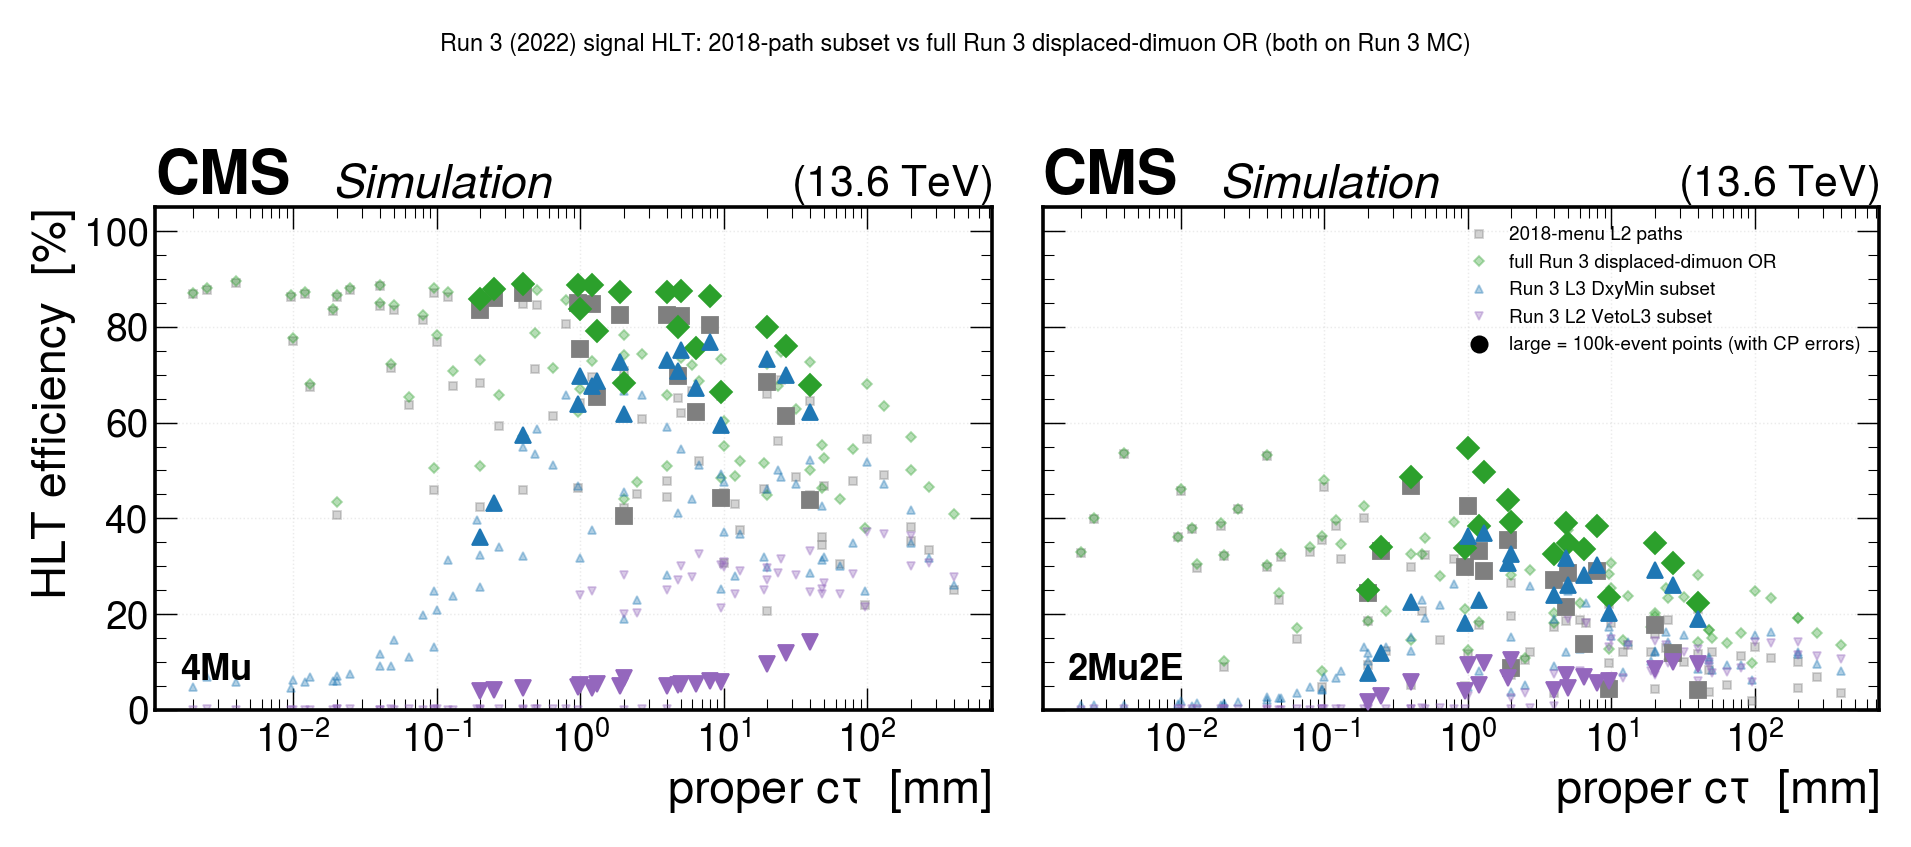

In [ ]:
P.fig_trigger()

### All four eras: canonical trigger table with exclusive marginals

Full-grid scan of every era at final statistics. Besides the inclusive group efficiencies, the
**exclusive marginal** x(family) = events accepted *only* via that family — the efficiency lost
if it were dropped from the OR. This is the input for deciding which families the analysis
adopts (each family's marginal, over the luminosity where its paths exist, against its
scale-factor bookkeeping cost).

**4μ** — grid-mean HLT efficiency [%]:

| era | 2018-set → full OR (gain) | x2018 | xL3Dxy | xVetoL3 | xHybrid |
|---|---|---|---|---|---|
| 2022 | 62.5 → 70.3 (+7.8) | 2.4 | 5.3 | 1.2 | 0.0 |
| 2022EE | 62.4 → 71.1 (+8.7) | 2.2 | 3.6 | 1.3 | 0.5 |
| 2023 | 62.3 → 71.4 (+9.0) | 2.2 | 3.9 | 1.1 | 0.5 |
| 2023BPix | 62.5 → 71.5 (+9.1) | 2.2 | 3.9 | 1.1 | 0.5 |

**2μ2e**:

| era | 2018-set → full OR (gain) | x2018 | xL3Dxy | xVetoL3 | xHybrid |
|---|---|---|---|---|---|
| 2022 | 20.9 → 28.1 (+7.2) | 2.3 | 4.9 | 1.1 | 0.0 |
| 2022EE | 20.9 → 29.4 (+8.5) | 2.1 | 3.2 | 1.3 | 0.7 |
| 2023 | 20.8 → 29.6 (+8.8) | 2.0 | 3.3 | 1.2 | 0.7 |
| 2023BPix | 20.8 → 29.7 (+8.9) | 2.1 | 3.4 | 1.2 | 0.7 |

The pattern is era-stable: the 2018-set baseline is identical everywhere (the Run 2 anchor is
*not* redundant — up to ~22% exclusive at heavy/prompt points), the L3-DxyMin family is the
largest Run 3 addition (up to ~24% exclusive at light/displaced points), VetoL3 is modest but
real, and the hybrid family is nearly redundant (≤0.7% mean exclusive) — a natural drop
candidate. In 2022 (no hybrid/cosmic-seeded-VetoL3 paths in the menu) their acceptance is
absorbed by L3-DxyMin, whose marginal is correspondingly larger there. Note these are
grid-means over the full phase space of our signal points; per-point values in the committed
trig_grid_*.json.

## 10. Note on running the full analysis

These samples are **gen-valid**. The coffea `SidmProcessor` does not yet run on Run 3 nano out of the box —
(1) it assumes Run 2 electron-ID branch names (`mvaFall17V2noIso_WPL`) and a `mass` field, and (2)
`sidm/configs/run_periods.yaml` has only `2018`, so `postprocess`'s lumi lookup raises `KeyError` for the
Run 3 eras. A Run 3 adaptation pass (electron ID + a Run 3 `run_periods` entry) is needed before the samples
can be processed with the full selection. Tracked separately.